In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from sklearn.cluster import MeanShift

In [3]:
import locale
import matplotlib as mpl

locale.setlocale(locale.LC_NUMERIC, "pt_BR.utf8")
plt.rcParams['axes.formatter.use_locale'] = True

# Configure text rendering to match your document's LaTeX engine
mpl.rcParams.update({
    "pgf.texsystem": "pdflatex", 
    "font.family": "serif",      # Matches standard LaTeX Computer Modern Font
    "text.usetex": True,         # Forces LaTeX text processing
    "pgf.rcfonts": False,        # Ignores default Python fonts
})

In [4]:
pd.options.display.max_seq_items = 2000

np.random.seed(84)
random.seed(84)

reconciled_data = pd.read_pickle('reconciled_data.pkl')

kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

kinetic_data['cluster'] = clustering.labels_

cluster_set = list(set(kinetic_data.cluster))

index_clusters = kinetic_data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [5]:
kinetic_data = pd.read_pickle('kinetic_data_dwsim.pkl')

In [6]:
cols_Fout_exp = [
    'F_H2_s_mol_s', 'F_CH4_s_mol_s', 'F_CO_s_mol_s', 'F_CO2_s_mol_s',
       'F_C2H4_s_mol_s', 'F_C2H6_s_mol_s', 'F_C3H8_s_mol_s', 'F_H2O_s_mol_s',
    'F_C9', 'F_C10', 'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16',
       'F_C17', 'F_C18', 'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24',
       'F_C25', 'F_C26', 'F_C27', 'F_C28', 'F_C29', 'F_C30',
       'F_Olef_C9', 'F_Olef_C10', 'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13',
       'F_Olef_C14', 'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
          ]

In [7]:
cols_Fout_dwsim = [
 'F_Hydrogen_out_dwsim',
 'F_Methane_out_dwsim',
 'F_Carbon monoxide_out_dwsim',
 'F_Carbon dioxide_out_dwsim',
 'F_Ethylene_out_dwsim',
 'F_Ethane_out_dwsim',
 'F_Propane_out_dwsim',
 'F_Water_out_dwsim',
 # 'F_N-butane_out_dwsim',
 # 'F_N-pentane_out_dwsim',
 # 'F_N-hexane_out_dwsim',
 # 'F_N-heptane_out_dwsim',
 # 'F_N-octane_out_dwsim',
 'F_N-nonane_out_dwsim',
 'F_N-decane_out_dwsim',
 'F_N-undecane_out_dwsim',
 'F_N-dodecane_out_dwsim',
 'F_N-tridecane_out_dwsim',
 'F_N-tetradecane_out_dwsim',
 'F_N-pentadecane_out_dwsim',
 'F_N-hexadecane_out_dwsim',
 'F_N-heptadecane_out_dwsim',
 'F_N-octadecane_out_dwsim',
 'F_N-nonadecane_out_dwsim',
 'F_N-eicosane_out_dwsim',
 'F_N-heneicosane_out_dwsim',
 'F_N-docosane_out_dwsim',
 'F_N-tricosane_out_dwsim',
 'F_N-tetracosane_out_dwsim',
 'F_N-pentacosane_out_dwsim',
 'F_N-hexacosane_out_dwsim',
 'F_N-heptacosane_out_dwsim',
 'F_N-octacosane_out_dwsim',
 'F_N-nonacosane_out_dwsim',
 'F_Triacontane_out_dwsim',
 # 'F_Propylene_out_dwsim',
 # 'F_1-butene_out_dwsim',
 # 'F_1-hexene_out_dwsim',
 # 'F_1-heptene_out_dwsim',
 # 'F_1-octene_out_dwsim',
 'F_1-nonene_out_dwsim',
 'F_1-decene_out_dwsim',
 'F_1-undecene_out_dwsim',
 'F_1-dodecene_out_dwsim',
 'F_1-Tridecene_out_dwsim',
 'F_1-tetradecene_out_dwsim',
 'F_1-Pentadecene_out_dwsim',
 'F_1-hexadecene_out_dwsim',
 'F_1-Heptadecene_out_dwsim',
 'F_1-octadecene_out_dwsim',
 # 'F_Hentriacontane_out_dwsim',
 # 'F_Dotriacontane_out_dwsim',
 # 'F_Tritriacontane_out_dwsim',
 # 'F_Tetratriacontane_out_dwsim',
 # 'F_Pentatriacontane_out_dwsim',
 # 'F_Hexatriacontane_out_dwsim',
 # 'F_1-pentene_out_dwsim',
                  ]

In [8]:
comp_dict_dwsim = {'F_Hydrogen_out_dwsim': '$\\mathrm{H_2}$',
 'F_Methane_out_dwsim': '$\\mathrm{CH_4}$',
 'F_Carbon monoxide_out_dwsim': '$\\mathrm{CO}$',
 'F_Carbon dioxide_out_dwsim': '$\\mathrm{CO_2}$',
 'F_Ethylene_out_dwsim': '$\\mathrm{C_2 H_4}$',
 'F_Ethane_out_dwsim': '$\\mathrm{C_2 H_6}$',
 'F_Propane_out_dwsim': '$\\mathrm{C_3 H_8}$',
 'F_Water_out_dwsim': '$\\mathrm{H_2 O}$',
 'F_N-nonane_out_dwsim': '$\\mathrm{C_9 H_{20}}$',
 'F_N-decane_out_dwsim': '$\\mathrm{C_{10} H_{22}}$',
 'F_N-undecane_out_dwsim': '$\\mathrm{C_{11} H_{24}}$',
 'F_N-dodecane_out_dwsim': '$\\mathrm{C_{12} H_{26}}$',
 'F_N-tridecane_out_dwsim': '$\\mathrm{C_{13} H_{28}}$',
 'F_N-tetradecane_out_dwsim': '$\\mathrm{C_{14} H_{30}}$',
 'F_N-pentadecane_out_dwsim': '$\\mathrm{C_{15} H_{32}}$',
 'F_N-hexadecane_out_dwsim': '$\\mathrm{C_{16} H_{34}}$',
 'F_N-heptadecane_out_dwsim': '$\\mathrm{C_{17} H_{36}}$',
 'F_N-octadecane_out_dwsim': '$\\mathrm{C_{18} H_{38}}$',
 'F_N-nonadecane_out_dwsim': '$\\mathrm{C_{19} H_{40}}$',
 'F_N-eicosane_out_dwsim': '$\\mathrm{C_{20} H_{42}}$',
 'F_N-heneicosane_out_dwsim': '$\\mathrm{C_{21} H_{44}}$',
 'F_N-docosane_out_dwsim': '$\\mathrm{C_{22} H_{46}}$',
 'F_N-tricosane_out_dwsim': '$\\mathrm{C_{23} H_{48}}$',
 'F_N-tetracosane_out_dwsim': '$\\mathrm{C_{24} H_{50}}$',
 'F_N-pentacosane_out_dwsim': '$\\mathrm{C_{25} H_{52}}$',
 'F_N-hexacosane_out_dwsim': '$\\mathrm{C_{26} H_{54}}$',
 'F_N-heptacosane_out_dwsim': '$\\mathrm{C_{27} H_{56}}$',
 'F_N-octacosane_out_dwsim': '$\\mathrm{C_{28} H_{58}}$',
 'F_N-nonacosane_out_dwsim': '$\\mathrm{C_{29} H_{60}}$',
 'F_Triacontane_out_dwsim': '$\\mathrm{C_{30} H_{62}}$',
 'F_1-nonene_out_dwsim': '$\\mathrm{C_9 H_{18}}$',
 'F_1-decene_out_dwsim': '$\\mathrm{C_{10} H_{20}}$',
 'F_1-undecene_out_dwsim': '$\\mathrm{C_{11} H_{22}}$',
 'F_1-dodecene_out_dwsim': '$\\mathrm{C_{12} H_{24}}$',
 'F_1-Tridecene_out_dwsim': '$\\mathrm{C_{13} H_{26}}$',
 'F_1-tetradecene_out_dwsim': '$\\mathrm{C_{14} H_{28}}$',
 'F_1-Pentadecene_out_dwsim': '$\\mathrm{C_{15} H_{30}}$',
 'F_1-hexadecene_out_dwsim': '$\\mathrm{C_{16} H_{32}}$',
 'F_1-Heptadecene_out_dwsim': '$\\mathrm{C_{17} H_{34}}$',
 'F_1-octadecene_out_dwsim': '$\\mathrm{C_{18} H_{36}}$'}

In [9]:
comp_dict_exp = {
    'F_H2_s_mol_s': r'$\mathrm{H_2}$',
    'F_CH4_s_mol_s': r'$\mathrm{CH_4}$',
    'F_CO_s_mol_s': r'$\mathrm{CO}$',
    'F_CO2_s_mol_s': r'$\mathrm{CO_2}$',
    'F_C2H4_s_mol_s' : r'$\mathrm{C_2 H_4}$',
    'F_C2H6_s_mol_s': r'$\mathrm{C_2 H_6}$',
    'F_C3H8_s_mol_s': r'$\mathrm{C_3 H_8}$',
    'F_H2O_s_mol_s': r'$\mathrm{H_2 O}$',
    'F_C9': r'$\mathrm{C_9 H_{20}}$',
    'F_C10': r'$\mathrm{C_{10} H_{22}}$',
    'F_C11': r'$\mathrm{C_{11} H_{24}}$',
    'F_C12': r'$\mathrm{C_{12} H_{26}}$',
    'F_C13': r'$\mathrm{C_{13} H_{28}}$',
    'F_C14': r'$\mathrm{C_{14} H_{30}}$',
    'F_C15': r'$\mathrm{C_{15} H_{32}}$',
    'F_C16': r'$\mathrm{C_{16} H_{34}}$',
    'F_C17': r'$\mathrm{C_{17} H_{36}}$',
    'F_C18': r'$\mathrm{C_{18} H_{38}}$',
    'F_C19': r'$\mathrm{C_{19} H_{40}}$',
    'F_C20': r'$\mathrm{C_{20} H_{42}}$',
    'F_C21': r'$\mathrm{C_{21} H_{44}}$',
    'F_C22': r'$\mathrm{C_{22} H_{46}}$',
    'F_C23': r'$\mathrm{C_{23} H_{48}}$',
    'F_C24': r'$\mathrm{C_{24} H_{50}}$',
    'F_C25': r'$\mathrm{C_{25} H_{52}}$',
    'F_C26': r'$\mathrm{C_{26} H_{54}}$',
    'F_C27': r'$\mathrm{C_{27} H_{56}}$',
    'F_C28': r'$\mathrm{C_{28} H_{58}}$',
    'F_C29': r'$\mathrm{C_{29} H_{60}}$',
    'F_C30': r'$\mathrm{C_{30} H_{62}}$',
    'F_Olef_C9': r'$\mathrm{C_9 H_{18}}$',
    'F_Olef_C10': r'$\mathrm{C_{10} H_{20}}$',
    'F_Olef_C11': r'$\mathrm{C_{11} H_{22}}$',
    'F_Olef_C12': r'$\mathrm{C_{12} H_{24}}$',
    'F_Olef_C13': r'$\mathrm{C_{13} H_{26}}$',
    'F_Olef_C14': r'$\mathrm{C_{14} H_{28}}$',
    'F_Olef_C15': r'$\mathrm{C_{15} H_{30}}$',
    'F_Olef_C16': r'$\mathrm{C_{16} H_{32}}$',
    'F_Olef_C17': r'$\mathrm{C_{17} H_{34}}$',
    'F_Olef_C18': r'$\mathrm{C_{18} H_{36}}$'}

In [10]:
leg_labels = {'$\\mathrm{H_2}$': '$\\mathrm{H_2}$',
 '$\\mathrm{CH_4}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{CO}$': '$\\mathrm{CO}$',
 '$\\mathrm{CO_2}$': '$\\mathrm{CO_2}$',
 '$\\mathrm{C_2 H_4}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_2 H_6}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_3 H_8}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{H_2 O}$': '$\\mathrm{H_2 O}$',
 '$\\mathrm{C_9 H_{20}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{10} H_{22}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{11} H_{24}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{12} H_{26}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{13} H_{28}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{14} H_{30}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{15} H_{32}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{16} H_{34}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{17} H_{36}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{18} H_{38}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{19} H_{40}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{20} H_{42}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{21} H_{44}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{22} H_{46}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{23} H_{48}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{24} H_{50}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{25} H_{52}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{26} H_{54}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{27} H_{56}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{28} H_{58}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{29} H_{60}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_{30} H_{62}}$': '$\\mathrm{C_{n} H_{2n+2}}$',
 '$\\mathrm{C_9 H_{18}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{10} H_{20}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{11} H_{22}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{12} H_{24}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{13} H_{26}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{14} H_{28}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{15} H_{30}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{16} H_{32}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{17} H_{34}}$': '$\\mathrm{C_{n} H_{2n}}$',
 '$\\mathrm{C_{18} H_{36}}$': '$\\mathrm{C_{n} H_{2n}}$'}

In [11]:
Fout_exp = kinetic_data[cols_Fout_exp]
Fout_exp['training'] = loc_training
Fout_exp['kin_index'] = kinetic_data.index
Fout_exp = Fout_exp.rename(columns=comp_dict_exp) 

Fout_dwsim = kinetic_data[cols_Fout_dwsim]
Fout_dwsim['training'] = loc_training
Fout_dwsim['kin_index'] = kinetic_data.index
Fout_dwsim = Fout_dwsim.rename(columns=comp_dict_dwsim) 

In [12]:
# have to reorder columns
Fout_exp = Fout_exp[Fout_dwsim.columns]

In [13]:
Fout_dwsim = Fout_dwsim.melt(id_vars = ['training', 'kin_index'],
                             var_name = 'component',
                             value_name = 'Fout_dwsim')

In [14]:
Fout_exp = Fout_exp.melt(id_vars = ['training', 'kin_index'],
                         var_name = 'component',
                         value_name = 'Fout_exp')

In [15]:
plotF = pd.concat((Fout_exp, Fout_dwsim.Fout_dwsim), axis = 'columns')

In [16]:
plotF['legend'] = plotF['component'].map(leg_labels)

In [17]:
# plotF = plotF.groupby(['kin_index', 'legend']).sum()

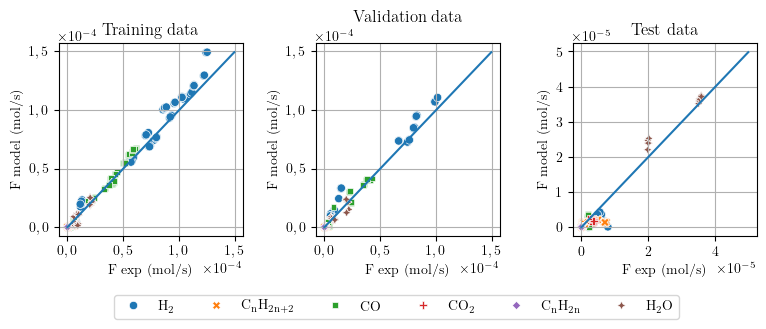

In [18]:
fig, axs = plt.subplots(1,3, figsize=(9,2.5))
plt.subplots_adjust(hspace=0.4, wspace = 0.4)
max_xy = max(plotF.Fout_exp.max(), plotF.Fout_dwsim.max())
min_xy = min(plotF.Fout_exp.min(), plotF.Fout_dwsim.min())

sns.scatterplot(
                data=plotF.loc[plotF['kin_index'].isin(idx_training)], 
                x='Fout_exp', 
                y='Fout_dwsim', 
                ax = axs[0],
                hue = 'legend',
                style = 'legend',
)

axs[0].plot((0, max_xy), (0, max_xy))
axs[0].set_title('Training data')
axs[0].set_xlabel('F exp (mol/s)')
axs[0].set_ylabel('F model (mol/s)')
axs[0].grid('both')
axs[0].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[0].get_legend().remove()

sns.scatterplot(
                data=plotF.loc[plotF['kin_index'].isin(idx_validation)], 
                x='Fout_exp', 
                y='Fout_dwsim', 
                ax = axs[1],
                hue = 'legend',
                style = 'legend',
)


axs[1].plot((0, max_xy), (0, max_xy))
axs[1].set_title('Validation data')
axs[1].set_xlabel('F exp (mol/s)')
axs[1].set_ylabel('F model (mol/s)')
axs[1].grid('both')
axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[1].get_legend().remove()

sns.scatterplot(
                data=plotF.loc[plotF['kin_index'].isin(idx_test)], 
                x='Fout_exp', 
                y='Fout_dwsim', 
                ax = axs[2],
                hue = 'legend',
                style = 'legend',
)


axs[2].plot((0, max_xy/3), (0, max_xy/3))
axs[2].set_title('Test data')
axs[2].set_xlabel('F exp (mol/s)')
axs[2].set_ylabel('F model (mol/s)')
axs[2].grid('both')
# axs[2].set_yscale('log')
# axs[2].set_xscale('log')
axs[2].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[2].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.25), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)

fig_name = 'Fout_parity_dwsim.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

In [19]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 '$\\mathrm{CH_4}$':          16,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{CO_2}$':          44,
 '$\\mathrm{C_2 H_4}$':        2*12 + 4,
 '$\\mathrm{C_2 H_6}$':        2*12 + 6,
 '$\\mathrm{C_3 H_8}$':        3*12 + 8,
 '$\\mathrm{H_2 O}$':         18,
 '$\\mathrm{C_9 H_{20}}$':     9*12 + 20,
 '$\\mathrm{C_{10} H_{22}}$': 10*12 + 22,
 '$\\mathrm{C_{11} H_{24}}$': 11*12 + 24,
 '$\\mathrm{C_{12} H_{26}}$': 12*12 + 26,
 '$\\mathrm{C_{13} H_{28}}$': 13*12 + 28,
 '$\\mathrm{C_{14} H_{30}}$': 14*12 + 30,
 '$\\mathrm{C_{15} H_{32}}$': 15*12 + 32,
 '$\\mathrm{C_{16} H_{34}}$': 16*12 + 34,
 '$\\mathrm{C_{17} H_{36}}$': 17*12 + 36,
 '$\\mathrm{C_{18} H_{38}}$': 18*12 + 38,
 '$\\mathrm{C_{19} H_{40}}$': 19*12 + 40,
 '$\\mathrm{C_{20} H_{42}}$': 20*12 + 42,
 '$\\mathrm{C_{21} H_{44}}$': 21*12 + 44,
 '$\\mathrm{C_{22} H_{46}}$': 22*12 + 46,
 '$\\mathrm{C_{23} H_{48}}$': 23*12 + 48,
 '$\\mathrm{C_{24} H_{50}}$': 24*12 + 50,
 '$\\mathrm{C_{25} H_{52}}$': 25*12 + 52,
 '$\\mathrm{C_{26} H_{54}}$': 26*12 + 54,
 '$\\mathrm{C_{27} H_{56}}$': 27*12 + 56,
 '$\\mathrm{C_{28} H_{58}}$': 28*12 + 58,
 '$\\mathrm{C_{29} H_{60}}$': 29*12 + 60,
 '$\\mathrm{C_{30} H_{62}}$': 30*12 + 62,
 '$\\mathrm{C_9 H_{18}}$':     9*12 + 18,
 '$\\mathrm{C_{10} H_{20}}$': 10*12 + 20,
 '$\\mathrm{C_{11} H_{22}}$': 11*12 + 22,
 '$\\mathrm{C_{12} H_{24}}$': 12*12 + 24,
 '$\\mathrm{C_{13} H_{26}}$': 13*12 + 26,
 '$\\mathrm{C_{14} H_{28}}$': 14*12 + 28,
 '$\\mathrm{C_{15} H_{30}}$': 15*12 + 30,
 '$\\mathrm{C_{16} H_{32}}$': 16*12 + 32,
 '$\\mathrm{C_{17} H_{34}}$': 17*12 + 34,
 '$\\mathrm{C_{18} H_{36}}$': 18*12 + 36}

In [20]:
plotF['MM (g/mol)'] = plotF.component.map(molar_mass_dict)

In [21]:
plotF[r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_exp']
)

plotF[r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'] = (
    86400 * plotF['MM (g/mol)'] * plotF['Fout_dwsim']
)

In [22]:
plot_m = plotF.groupby(['kin_index', 'legend']).sum()

In [23]:
plot_m[r'$\sigma \dot{m}_{\mathrm{out,exp}}$ (g/d)'] = plot_m[r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'] * 0.05

In [24]:
sigma_m_out_Mousavi = pd.read_pickle('plot_mass_flows.pkl')[['sigma_m_out_Mousavi_low (g/d)', 'sigma_m_out_Mousavi_high (g/d)']]

In [25]:
plot_m['sigma_m_out_Mousavi_low (g/d)'] = sigma_m_out_Mousavi['sigma_m_out_Mousavi_low (g/d)']
plot_m['sigma_m_out_Mousavi_high (g/d)'] = sigma_m_out_Mousavi['sigma_m_out_Mousavi_high (g/d)']

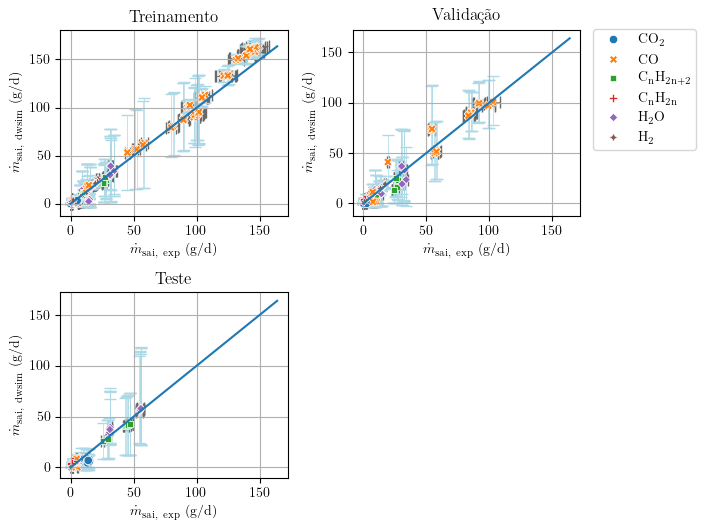

In [39]:
fig, axs = plt.subplots(2,2, figsize=(6,5.4))
axs = axs.flatten()
plt.subplots_adjust(hspace=0.4, wspace = 0.4)
max_xy = max(plotF[r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'].max(), 
             plotF[r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'].max())
scale = 'linear'

axs[0].errorbar(
        x=plot_m.loc[idx_training, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_training, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        xerr=plot_m.loc[idx_training, r'$\sigma \dot{m}_{\mathrm{out,exp}}$ (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="dimgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

axs[0].errorbar(
        x=plot_m.loc[idx_training, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_training, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        yerr=plot_m.loc[idx_training, ['sigma_m_out_Mousavi_low (g/d)', 'sigma_m_out_Mousavi_high (g/d)']].to_numpy().T,
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

sns.scatterplot(
                data=plot_m.loc[idx_training], 
                x=r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)', 
                ax = axs[0],
                hue = 'legend',
                style = 'legend',
)

axs[0].plot((0, max_xy), (0, max_xy))
axs[0].set_title('Treinamento')
axs[0].grid('both')
axs[0].set_xscale(scale)
axs[0].set_yscale(scale)
# axs[0].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[0].get_legend().remove()

axs[1].errorbar(
        x=plot_m.loc[idx_validation, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_validation, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        xerr=plot_m.loc[idx_validation, r'$\sigma \dot{m}_{\mathrm{out,exp}}$ (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="dimgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

axs[1].errorbar(
        x=plot_m.loc[idx_validation, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_validation, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        yerr=plot_m.loc[idx_validation, ['sigma_m_out_Mousavi_low (g/d)', 'sigma_m_out_Mousavi_high (g/d)']].to_numpy().T,
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

sns.scatterplot(
                data=plot_m.loc[idx_validation], 
                x=r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)', 
                ax = axs[1],
                hue = 'legend',
                style = 'legend',
)


axs[1].plot((0, max_xy), (0, max_xy))
axs[1].set_title('Validação')
axs[1].grid('both')
axs[1].set_xscale(scale)
axs[1].set_yscale(scale)
# axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[1].get_legend().remove()

axs[2].errorbar(
        x=plot_m.loc[idx_test, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_test, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        xerr=plot_m.loc[idx_test, r'$\sigma \dot{m}_{\mathrm{out,exp}}$ (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="dimgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

axs[2].errorbar(
        x=plot_m.loc[idx_test, r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'], 
        y=plot_m.loc[idx_test, r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)'], 
        yerr=plot_m.loc[idx_test, ['sigma_m_out_Mousavi_low (g/d)', 'sigma_m_out_Mousavi_high (g/d)']].to_numpy().T,
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

sns.scatterplot(
                data=plot_m.loc[idx_test], 
                x=r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)', 
                y=r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)', 
                ax = axs[2],
                hue = 'legend',
                style = 'legend',
)


axs[2].plot((0, max_xy), (0, max_xy))
axs[2].set_title('Teste')
axs[2].grid('both')
axs[2].set_xscale(scale)
axs[2].set_yscale(scale)
# axs[1].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
axs[2].get_legend().remove()

axs[3].remove()

handles, labels = axs[1].get_legend_handles_labels()

fig.legend(handles, labels, 
           bbox_to_anchor=(1.18, 0.95),
           ncol=1, 
           frameon=True)

plt.tight_layout()

fig_name = 'figure-m_out_parity_dwsim.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Tese/LaTeX_source_tese/figures/cinética_FTS/'+fig_name, 
            bbox_inches = 'tight')

In [27]:
SSR = (plot_m[r'$\dot{m}_{\mathrm{sai,~exp}}$ (g/d)'] - plot_m[r'$\dot{m}_{\mathrm{sai,~dwsim}}$ (g/d)']).pow(2).sum()

In [28]:
SSR

np.float64(15834.44912585917)